# Project: Utilization of hospital beds during epidemics

We use our code from week 1 day 3 where we learned about Poisson arrival processes. Now we have three arrival processes akin to three resturants in the original problem. We model their arrivals individually and log them. Later on we then find out whether they would be transferred based on the number of available beds. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
from tqdm import tqdm
from scipy.optimize import brentq

In [56]:
def rateA(t):
    if t < 0 or t > 365:
        raise ValueError("t must be between 0 and 365")
    else:
        if t == 0:
            return -(1/3650)*t**2 + (1/10)*t + 1   
        return -(1/3650)*t**2 + (1/10)*t

def rateB(t):
    if t < 0 or t > 365:
        raise ValueError("t must be between 0 and 365")
    else:
        return (1/5)*rateA(t)

def rateC(t):
    return 6

muA = np.log(4*np.sqrt(2))
muB = np.log(6*np.sqrt(2))
muC = np.log(5*np.sqrt(2))
sigmaA = sigmaB = sigmaC = np.sqrt(np.log(2))

total_beds = 75

bedsA = 20
bedsB = 20
bedsC = total_beds - bedsA - bedsB

T = 365
rng = np.random.default_rng()
def simulate_hospital(bedsA, bedsB, bedsC, T):
    events = []
    # Ward A
    arrivals_A = []
    t = 0.0
    while t < T:
        t += rng.exponential(scale=1.0 / rateA(t))
        if t < T:
            arrivals_A.append(t)
    # Ward B
    arrivals_B = []
    t = 0.0
    while t < T:
        t += rng.exponential(scale=1.0 / rateB(t))
        if t < T:
            arrivals_B.append(t)

    # Ward C
    arrivals_C = []
    t = 0.0
    while t < T:
        t += rng.exponential(scale=1.0 / rateC(t))
        if t < T:
            arrivals_C.append(t)

    # Create event list
    events = []
    for t in arrivals_A:
        events.append((t, 'A'))
    for t in arrivals_B:
        events.append((t, 'B'))
    for t in arrivals_C:
        events.append((t, 'C'))
    events.sort(key=lambda x: x[0])

    deps_A = []
    deps_B = []
    deps_C = []

    blocked_A = 0
    blocked_B = 0
    blocked_C = 0
    transferred_B_to_A = 0

    for t, ward in events:

        # Discharge patients before processing arrival
        while deps_A and deps_A[0] <= t:
            heapq.heappop(deps_A)

        while deps_B and deps_B[0] <= t:
            heapq.heappop(deps_B)

        while deps_C and deps_C[0] <= t:
            heapq.heappop(deps_C)

        if ward == 'A':

            if len(deps_A) < bedsA:
                los = rng.lognormal(muA, sigmaA)
                heapq.heappush(deps_A, t + los)

            else:
                blocked_A += 1

        elif ward == 'B':

            if len(deps_B) < bedsB:
                los = rng.lognormal(muB, sigmaB)
                heapq.heappush(deps_B, t + los)

            elif len(deps_A) < bedsA:
                los = rng.lognormal(muB, sigmaB)
                heapq.heappush(deps_A, t + los)
                transferred_B_to_A += 1

            else:
                blocked_B += 1

        elif ward == 'C':

            if len(deps_C) < bedsC:
                los = rng.lognormal(muC, sigmaC)
                heapq.heappush(deps_C, t + los)

            else:
                blocked_C += 1

    return {
        "blocked_A": blocked_A,
        "blocked_B": blocked_B,
        "blocked_C": blocked_C,
        "transferred_B_to_A": transferred_B_to_A,
        "Total blocked": blocked_A + blocked_B + blocked_C,
        "arrivals_A": len(arrivals_A),
        "arrivals_B": len(arrivals_B),
        "arrivals_C": len(arrivals_C),
        "Total arrivals": len(arrivals_A) + len(arrivals_B) + len(arrivals_C),
        "P_block_A": blocked_A / len(arrivals_A) if len(arrivals_A) > 0 else 0,
        "P_block_B": (blocked_B + transferred_B_to_A) / len(arrivals_B) if len(arrivals_B) > 0 else 0,
        "P_block_C": blocked_C / len(arrivals_C) if len(arrivals_C) > 0 else 0

    }

n_replications = 1000
results = []
for _ in tqdm(range(n_replications), desc="Simulating hospital"):
    res = simulate_hospital(bedsA, bedsB, bedsC, T)
    results.append(res)

metric_names = [
    "blocked_A",
    "blocked_B",
    "blocked_C",
    "transferred_B_to_A",
    "Total blocked",
    "arrivals_A",
    "arrivals_B",
    "arrivals_C",
    "Total arrivals",
    "P_block_A",
    "P_block_B",
    "P_block_C",
]

z = 1.96  # 95% normal CI
for metric in metric_names:
    values = np.array([res[metric] for res in results], dtype=float)
    mean_val = np.mean(values)
    std_val = np.std(values, ddof=1)
    se = std_val / np.sqrt(n_replications)
    ci_low = mean_val - z * se
    ci_high = mean_val + z * se
    print(f"{metric}: {mean_val:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")


Simulating hospital: 100%|██████████| 1000/1000 [00:09<00:00, 101.29it/s]

blocked_A: 1320.7150 (95% CI: [1301.1813, 1340.2487])
blocked_B: 33.4510 (95% CI: [32.4046, 34.4974])
blocked_C: 931.9470 (95% CI: [928.5636, 935.3304])
transferred_B_to_A: 14.4030 (95% CI: [13.6574, 15.1486])
Total blocked: 2286.1130 (95% CI: [2265.7940, 2306.4320])
arrivals_A: 2056.6860 (95% CI: [2026.8301, 2086.5419])
arrivals_B: 406.4320 (95% CI: [400.0495, 412.8145])
arrivals_C: 2187.6630 (95% CI: [2184.7548, 2190.5712])
Total arrivals: 4650.7810 (95% CI: [4620.5227, 4681.0393])
P_block_A: 0.6175 (95% CI: [0.6100, 0.6249])
P_block_B: 0.1107 (95% CI: [0.1081, 0.1134])
P_block_C: 0.4258 (95% CI: [0.4246, 0.4269])


We are modelling this as we would a homogenous poisson process, that is, each time we add our exponential distribution to $t$, we do it as if the rate is constant. This is okay for ward C, as the rate is constant here, but for ward A and B we need to estimate the time as a non-homogenous poisson process: 

For a non-homogeneous Poisson process (NHPP), the probability of an arrival in the next small interval depends on the future time:

$$P(N(t+h)−N(t)=1)\approx λ(t)h.$$

The waiting time until the next arrival is not exponential. Instead:

$$P(T > s) = \text{Exp}(\int_t^{t+s}\lambda(u)du)$$

which involves the integral of the rate function. This means that we in this case can use the integral:

$$\Lambda = \int_0^{t}\lambda(u)du = −\frac{t^3}{3\times 3650}​+\frac{t^2}{2\times 10}​.$$

We can then simulate the non-homogenous poisson process by simulating a standard poisson process in $\Lambda\text{-space}$ and then transforming it back to $\lambda$-space by solving:

$$\Lambda(t) = s$$

For ward A and B we can do it by solving it numerically between $0 \leq t \leq 365$.



In [4]:
def LambdaA(t):
    return -(t**3)/10950 + (t**2)/20

def LambdaA_inv(s):
    f = lambda t: LambdaA(t) - s
    return brentq(f, 0, 365)

def LambdaB(t):
    return (1/5)*(-(t**3)/10950 + (t**2)/20)

def LambdaB_inv(s):
    f = lambda t: LambdaB(t) - s
    return brentq(f, 0, 365)



In [6]:
def rateC(t):
    return 6

muA = np.log(4*np.sqrt(2))
muB = np.log(6*np.sqrt(2))
muC = np.log(5*np.sqrt(2))
sigmaA = sigmaB = sigmaC = np.sqrt(np.log(2))

total_beds = 75

bedsA = 20
bedsB = 20
bedsC = total_beds - bedsA - bedsB

T = 365
rng = np.random.default_rng(42)
def simulate_hospital(bedsA, bedsB, bedsC, T):
    events = []
    # Ward A
    arrivals_A = []
    t = 0.0
    S = 0
    while True:
        S += rng.exponential(1)
        if S > LambdaA(T):
            break
        t = LambdaA_inv(S)

        if t > T:
            break

        arrivals_A.append(t)
    # Ward B
    arrivals_B = []
    t = 0.0
    S = 0
    while True:
        S += rng.exponential(1)
        if S > LambdaB(T):
            break
        t = LambdaB_inv(S)

        if t > T:
            break

        arrivals_B.append(t)

    # Ward C
    arrivals_C = []
    t = 0.0
    while t < T:
        t += rng.exponential(scale=1.0 / rateC(t))
        if t < T:
            arrivals_C.append(t)

    # Create event list
    events = []
    for t in arrivals_A:
        events.append((t, 'A'))
    for t in arrivals_B:
        events.append((t, 'B'))
    for t in arrivals_C:
        events.append((t, 'C'))
    events.sort(key=lambda x: x[0])

    deps_A = []
    deps_B = []
    deps_C = []

    occupied_A_list = []
    occupied_B_list = []
    occupied_C_list = []

    blocked_A = 0
    blocked_B = 0
    blocked_C = 0
    transferred_B_to_A = 0
    occupied_A = 0
    occupied_B = 0
    occupied_C = 0
    area_A = 0
    area_B = 0
    area_C = 0

    last_t = 0

    for t, ward in events:
        dt = t - last_t

        #area_A += occupied_A * dt
        #area_B += occupied_B * dt
        #area_C += occupied_C * dt

        last_t = t

        # Discharge patients before processing arrival
        while deps_A and deps_A[0] <= t:
            heapq.heappop(deps_A)
            occupied_A -= 1

        while deps_B and deps_B[0] <= t:
            heapq.heappop(deps_B)
            occupied_B -= 1

        while deps_C and deps_C[0] <= t:
            heapq.heappop(deps_C)
            occupied_C -= 1

        if ward == 'A':

            if len(deps_A) < bedsA:
                los = rng.lognormal(muA, sigmaA)
                area_A += los
                heapq.heappush(deps_A, t + los)
                occupied_A += 1

            else:
                blocked_A += 1

        elif ward == 'B':

            if len(deps_B) < bedsB:
                los = rng.lognormal(muB, sigmaB)
                area_B += los
                heapq.heappush(deps_B, t + los)
                occupied_B += 1

            elif len(deps_A) < bedsA:
                los = rng.lognormal(muB, sigmaB)
                area_A += los
                heapq.heappush(deps_A, t + los)
                transferred_B_to_A += 1
                occupied_A += 1

            else:
                blocked_B += 1

        elif ward == 'C':

            if len(deps_C) < bedsC:
                los = rng.lognormal(muC, sigmaC)
                area_C += los
                heapq.heappush(deps_C, t + los)
                occupied_C += 1

            else:
                blocked_C += 1
        
        occupied_A_list.append(occupied_A)
        occupied_B_list.append(occupied_B)
        occupied_C_list.append(occupied_C)

    util_A = area_A / (bedsA * T)
    util_B = area_B / (bedsB * T)
    util_C = area_C / (bedsC * T)

    return {
        "blocked_A": blocked_A,
        "blocked_B": blocked_B + transferred_B_to_A,
        "blocked_C": blocked_C,
        "transferred_B_to_A": transferred_B_to_A,
        "Total blocked": blocked_A + blocked_B + blocked_C + transferred_B_to_A,
        "arrivals_A": len(arrivals_A),
        "arrivals_B": len(arrivals_B),
        "arrivals_C": len(arrivals_C),
        "Total arrivals": len(arrivals_A) + len(arrivals_B) + len(arrivals_C),
        "P_block_A": blocked_A / len(arrivals_A) if len(arrivals_A) > 0 else 0,
        "P_block_B": (blocked_B + transferred_B_to_A) / len(arrivals_B) if len(arrivals_B) > 0 else 0,
        "P_block_C": blocked_C / len(arrivals_C) if len(arrivals_C) > 0 else 0,
        "Probability all beds occupied": (blocked_A + blocked_B + blocked_C + transferred_B_to_A) / (len(arrivals_A) + len(arrivals_B) + len(arrivals_C)) if (len(arrivals_A) + len(arrivals_B) + len(arrivals_C)) > 0 else 0,
        "Utilization_A": util_A,
        "Utilization_B": util_B,
        "Utilization_C": util_C,
        "occupied_A_list": occupied_A_list,
        "occupied_B_list": occupied_B_list,
        "occupied_C_list": occupied_C_list,
        "P_occupiod_A": np.mean(occupied_A_list) / bedsA,
        "P_occupiod_B": np.mean(occupied_B_list) / bedsB,
        "P_occupiod_C": np.mean(occupied_C_list) / bedsC,

    }

n_replications = 1000
results = []
for _ in tqdm(range(n_replications), desc="Simulating hospital"):
    res = simulate_hospital(bedsA, bedsB, bedsC, T)
    results.append(res)

metric_names = [
    "blocked_A",
    "blocked_B",
    "blocked_C",
    "transferred_B_to_A",
    "Total blocked",
    "arrivals_A",
    "arrivals_B",
    "arrivals_C",
    "Total arrivals",
    "P_block_A",
    "P_block_B",
    "P_block_C",
    "Probability all beds occupied",
    "Utilization_A",
    "Utilization_B",
    "Utilization_C",
    "occupied_A_list",
    "occupied_B_list",
    "occupied_C_list",
    "P_occupiod_A",
    "P_occupiod_B",
    "P_occupiod_C",
]

z = 1.96  # 95% normal CI
for metric in metric_names:
    if metric not in ["occupied_A_list", "occupied_B_list", "occupied_C_list"]:
        values = np.array([res[metric] for res in results], dtype=float)
        mean_val = np.mean(values)
        std_val = np.std(values, ddof=1)
        se = std_val / np.sqrt(n_replications)
        ci_low = mean_val - z * se
        ci_high = mean_val + z * se
        print(f"{metric}: {mean_val:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")



Simulating hospital: 100%|██████████| 1000/1000 [01:30<00:00, 11.01it/s]

blocked_A: 1420.1620 (95% CI: [1417.0145, 1423.3095])
blocked_B: 52.0720 (95% CI: [51.0939, 53.0501])
blocked_C: 933.8030 (95% CI: [930.4790, 937.1270])
transferred_B_to_A: 12.8330 (95% CI: [12.5313, 13.1347])
Total blocked: 2406.0370 (95% CI: [2401.3738, 2410.7002])
arrivals_A: 2220.4590 (95% CI: [2217.5735, 2223.3445])
arrivals_B: 443.3990 (95% CI: [442.0901, 444.7079])
arrivals_C: 2189.9700 (95% CI: [2187.0307, 2192.9093])
Total arrivals: 4853.8280 (95% CI: [4849.5893, 4858.0667])
P_block_A: 0.6395 (95% CI: [0.6386, 0.6403])
P_block_B: 0.1166 (95% CI: [0.1146, 0.1185])
P_block_C: 0.4262 (95% CI: [0.4251, 0.4273])
Probability all beds occupied: 0.4956 (95% CI: [0.4950, 0.4963])
Utilization_A: 0.8987 (95% CI: [0.8979, 0.8994])
Utilization_B: 0.6445 (95% CI: [0.6426, 0.6463])
Utilization_C: 0.9830 (95% CI: [0.9826, 0.9835])
P_occupiod_A: 0.9373 (95% CI: [0.9369, 0.9377])
P_occupiod_B: 0.7028 (95% CI: [0.7011, 0.7046])
P_occupiod_C: 0.9687 (95% CI: [0.9686, 0.9689])


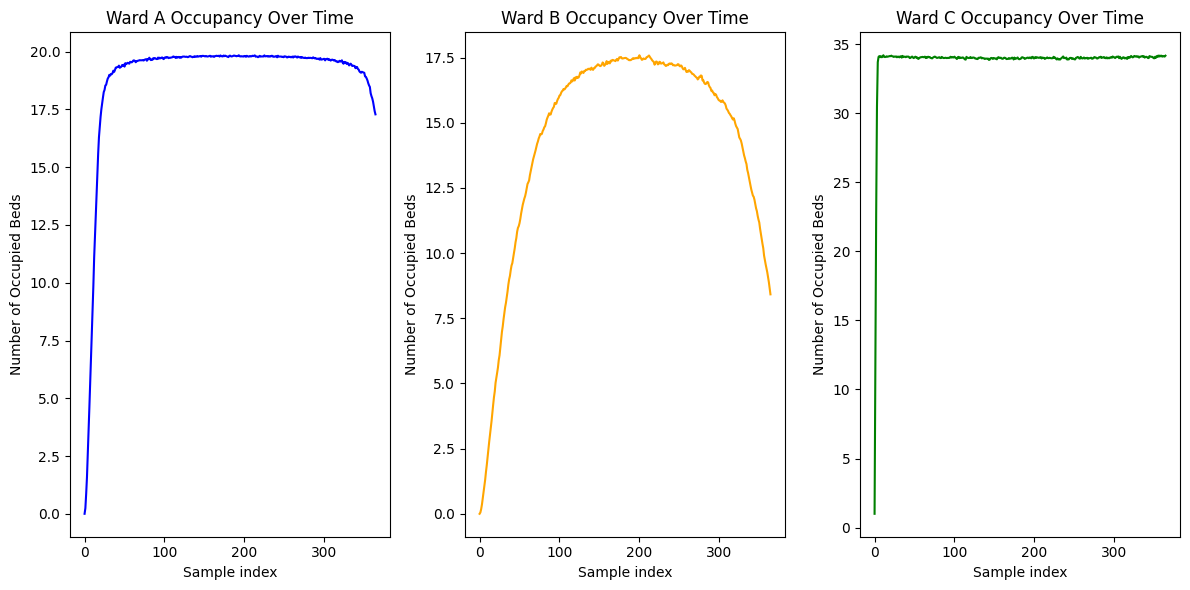

In [7]:
occupied_A_mean = []
occupied_B_mean = []
occupied_C_mean = []

# Find a common valid length across all replications and all wards
min_len_A = min(len(r["occupied_A_list"]) for r in results)
min_len_B = min(len(r["occupied_B_list"]) for r in results)
min_len_C = min(len(r["occupied_C_list"]) for r in results)
min_len = min(min_len_A, min_len_B, min_len_C)

# Choose how many points to plot (at most 365, and never more than min_len)
n_points = min(365, min_len)

# Indices guaranteed to be valid for every replication
indices = np.linspace(0, min_len - 1, n_points).astype(int)

for idx in indices:
    occupied_A_mean.append(np.mean([r["occupied_A_list"][idx] for r in results]))
    occupied_B_mean.append(np.mean([r["occupied_B_list"][idx] for r in results]))
    occupied_C_mean.append(np.mean([r["occupied_C_list"][idx] for r in results]))

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.title("Ward A Occupancy Over Time")
plt.xlabel("Sample index")
plt.ylabel("Number of Occupied Beds")
plt.plot(occupied_A_mean, color="blue")

plt.subplot(1, 3, 2)
plt.title("Ward B Occupancy Over Time")
plt.xlabel("Sample index")
plt.ylabel("Number of Occupied Beds")
plt.plot(occupied_B_mean, color="orange")

plt.subplot(1, 3, 3)
plt.title("Ward C Occupancy Over Time")
plt.xlabel("Sample index")
plt.ylabel("Number of Occupied Beds")
plt.plot(occupied_C_mean, color="green")

plt.tight_layout()
plt.show()

## Sensitivity Analysis
For this part we run through different combinations of beds between the three wards while making sure that the total number of beds are always 75. We do this by only changing the beds in A and B and then calculating the number of beds in C as a result of this.

In [8]:
def simulate_hospital_gridsearch(bedsA, bedsB, bedsC, T, events, arrivals_A, arrivals_B, arrivals_C):
    deps_A = []
    deps_B = []
    deps_C = []

    blocked_A = 0
    blocked_B = 0
    blocked_C = 0
    transferred_B_to_A = 0
    occupied_A = 0
    occupied_B = 0
    occupied_C = 0
    area_A = 0
    area_B = 0
    area_C = 0

    occupied_A_list = []
    occupied_B_list = []
    occupied_C_list = []

    last_t = 0

    for t, ward in events:
        dt = t - last_t

        #area_A += occupied_A * dt
        #area_B += occupied_B * dt
        #area_C += occupied_C * dt

        last_t = t

        # Discharge patients before processing arrival
        while deps_A and deps_A[0] <= t:
            heapq.heappop(deps_A)
            occupied_A -= 1

        while deps_B and deps_B[0] <= t:
            heapq.heappop(deps_B)
            occupied_B -= 1

        while deps_C and deps_C[0] <= t:
            heapq.heappop(deps_C)
            occupied_C -= 1

        if ward == 'A':

            if len(deps_A) < bedsA:
                los = rng.lognormal(muA, sigmaA)
                area_A += los
                heapq.heappush(deps_A, t + los)
                occupied_A += 1

            else:
                blocked_A += 1

        elif ward == 'B':

            if len(deps_B) < bedsB:
                los = rng.lognormal(muB, sigmaB)
                area_B += los
                heapq.heappush(deps_B, t + los)
                occupied_B += 1

            elif len(deps_A) < bedsA:
                los = rng.lognormal(muB, sigmaB)
                area_A += los
                heapq.heappush(deps_A, t + los)
                transferred_B_to_A += 1
                occupied_A += 1

            else:
                blocked_B += 1

        elif ward == 'C':

            if len(deps_C) < bedsC:
                los = rng.lognormal(muC, sigmaC)
                area_C += los
                heapq.heappush(deps_C, t + los)
                occupied_C += 1

            else:
                blocked_C += 1
        
        occupied_A_list.append(occupied_A)
        occupied_B_list.append(occupied_B)
        occupied_C_list.append(occupied_C)

    util_A = area_A / (bedsA * T)
    util_B = area_B / (bedsB * T)
    util_C = area_C / (bedsC * T)

    return {
        "blocked_A": blocked_A,
        "blocked_B": blocked_B + transferred_B_to_A,
        "blocked_C": blocked_C,
        "transferred_B_to_A": transferred_B_to_A,
        "Total blocked": blocked_A + blocked_B + blocked_C + transferred_B_to_A,
        "arrivals_A": len(arrivals_A),
        "arrivals_B": len(arrivals_B),
        "arrivals_C": len(arrivals_C),
        "Total arrivals": len(arrivals_A) + len(arrivals_B) + len(arrivals_C),
        "P_block_A": blocked_A / len(arrivals_A) if len(arrivals_A) > 0 else 0,
        "P_block_B": (blocked_B + transferred_B_to_A) / len(arrivals_B) if len(arrivals_B) > 0 else 0,
        "P_block_C": blocked_C / len(arrivals_C) if len(arrivals_C) > 0 else 0,
        "Probability all beds occupied": (blocked_A + blocked_B + blocked_C + transferred_B_to_A) / (len(arrivals_A) + len(arrivals_B) + len(arrivals_C)) if (len(arrivals_A) + len(arrivals_B) + len(arrivals_C)) > 0 else 0,
        "Utilization_A": util_A,
        "Utilization_B": util_B,
        "Utilization_C": util_C,
        "occupied_A_list": occupied_A_list,
        "occupied_B_list": occupied_B_list,
        "occupied_C_list": occupied_C_list,
        "P_occupiod_A": np.mean(occupied_A_list) / bedsA,
        "P_occupiod_B": np.mean(occupied_B_list) / bedsB,
        "P_occupiod_C": np.mean(occupied_C_list) / bedsC,

    }

In [72]:
rng = np.random.default_rng(42)
# Simulate arrivals before
events = []
# Ward A
arrivals_A = []
t = 0.0
S = 0
while True:
    S += rng.exponential(1)
    if S > LambdaA(T):
        break
    t = LambdaA_inv(S)

    if t > T:
        break

    arrivals_A.append(t)
# Ward B
arrivals_B = []
t = 0.0
S = 0
while True:
    S += rng.exponential(1)
    if S > LambdaB(T):
        break
    t = LambdaB_inv(S)

    if t > T:
        break

    arrivals_B.append(t)

# Ward C
arrivals_C = []
t = 0.0
while t < T:
    t += rng.exponential(scale=1.0 / rateC(t))
    if t < T:
        arrivals_C.append(t)

# Create event list
events = []
for t in arrivals_A:
    events.append((t, 'A'))
for t in arrivals_B:
    events.append((t, 'B'))
for t in arrivals_C:
    events.append((t, 'C'))
events.sort(key=lambda x: x[0])

total_beds = 75
num_beds_A = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]
num_beds_B = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]
n_replications = 100
grid_results = []
for bedsA in num_beds_A:
    for bedsB in num_beds_B:
        bedsC = total_beds - bedsA - bedsB
        if bedsC <= 0:
            continue

        config_results = []
        for _ in tqdm(
            range(n_replications),
            desc=f"Simulating for bedsA={bedsA}, bedsB={bedsB}, bedsC={bedsC}"
        ):
            res = simulate_hospital_gridsearch(bedsA, bedsB, bedsC, T, events, arrivals_A, arrivals_B, arrivals_C)
            config_results.append(res)
        total_blocked_values = np.array([r["Total blocked"] + r["transferred_B_to_A"] for r in config_results], dtype=float)
        mean_total_blocked = np.mean(total_blocked_values)
        mean_bed_utilization = np.mean([
            (r["Utilization_A"] + r["Utilization_B"] + r["Utilization_C"]) / 3 for r in config_results
        ])
        mean_transferred_B = np.mean([r["transferred_B_to_A"] for r in config_results])
        grid_results.append({
            "bedsA": bedsA,
            "bedsB": bedsB,
            "bedsC": bedsC,
            "mean_total_blocked": mean_total_blocked
        })

# Best configuration over mean_total_blocked and mean_bed_utilization
best_config = min(
        grid_results,
        key=lambda x: (x["mean_total_blocked"])
    )
print(
    f"Best configuration: bedsA={best_config['bedsA']}, "
    f"bedsB={best_config['bedsB']}, bedsC={best_config['bedsC']} "
    f"with mean total blocked={best_config['mean_total_blocked']:.4f}, "
)

Simulating for bedsA=65, bedsB=5, bedsC=5: 100%|██████████| 100/100 [00:00<00:00, 199.15it/s]

Best configuration: bedsA=25, bedsB=10, bedsC=40 with mean total blocked=2337.6300, 


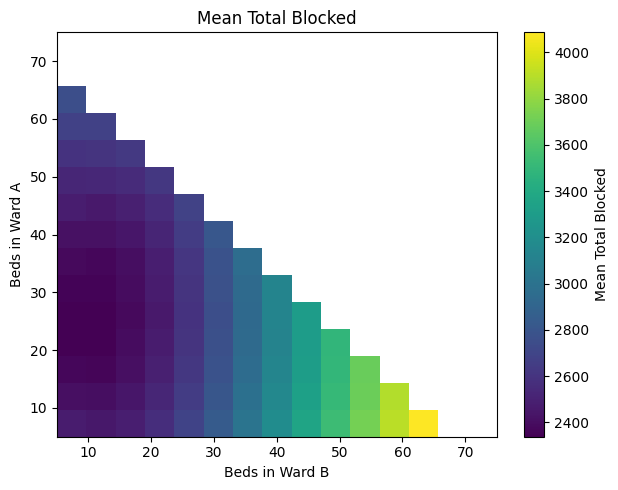

In [74]:
import matplotlib.pyplot as plt

# Pivot your grid_results into a matrix
pivot = np.full((len(num_beds_A), len(num_beds_B)), np.nan)
for r in grid_results:
    i = num_beds_A.index(r["bedsA"])
    j = num_beds_B.index(r["bedsB"])
    pivot[i, j] = r["mean_total_blocked"]

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(pivot, origin='lower', extent=(min(num_beds_B), max(num_beds_B), min(num_beds_A), max(num_beds_A)), aspect='auto')
plt.colorbar(label='Mean Total Blocked')
plt.xlabel('Beds in Ward B')
plt.ylabel('Beds in Ward A')
plt.title('Mean Total Blocked')
plt.tight_layout()

In [76]:
# Best configuration over mean_total_blocked and mean_bed_utilization
best_config = min(
        grid_results,
        key=lambda x: (x["mean_total_blocked"])
    )
print(
    f"Best configuration: bedsA={best_config['bedsA']}, "
    f"bedsB={best_config['bedsB']}, bedsC={best_config['bedsC']} "
    f"with mean total blocked={best_config['mean_total_blocked']:.4f}"
)

Best configuration: bedsA=25, bedsB=10, bedsC=40 with mean total blocked=2337.6300


In [77]:
# Simulate arrivals before
events = []
# Ward A
arrivals_A = []
t = 0.0
S = 0
while True:
    S += rng.exponential(1)
    if S > LambdaA(T):
        break
    t = LambdaA_inv(S)

    if t > T:
        break

    arrivals_A.append(t)
# Ward B
arrivals_B = []
t = 0.0
S = 0
while True:
    S += rng.exponential(1)
    if S > LambdaB(T):
        break
    t = LambdaB_inv(S)

    if t > T:
        break

    arrivals_B.append(t)

# Ward C
arrivals_C = []
t = 0.0
while t < T:
    t += rng.exponential(scale=1.0 / rateC(t))
    if t < T:
        arrivals_C.append(t)

# Create event list
events = []
for t in arrivals_A:
    events.append((t, 'A'))
for t in arrivals_B:
    events.append((t, 'B'))
for t in arrivals_C:
    events.append((t, 'C'))
events.sort(key=lambda x: x[0])
total_beds = 75
num_beds_A = [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
num_beds_B = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
n_replications = 100
grid_results = []

for bedsA in num_beds_A:
    for bedsB in num_beds_B:
        bedsC = total_beds - bedsA - bedsB
        if bedsC <= 0:
            continue

        config_results = []
        for _ in tqdm(
            range(n_replications),
            desc=f"Simulating for bedsA={bedsA}, bedsB={bedsB}, bedsC={bedsC}"
        ):
            res = simulate_hospital_gridsearch(bedsA, bedsB, bedsC, T, events, arrivals_A, arrivals_B, arrivals_C)
            config_results.append(res)

        total_blocked_values = np.array([r["Total blocked"] + r["transferred_B_to_A"] for r in config_results], dtype=float)
        mean_total_blocked = np.mean(total_blocked_values)
        mean_bed_utilization = np.mean([
            (r["Utilization_A"] + r["Utilization_B"] + r["Utilization_C"]) / 3 for r in config_results
        ])
        mean_transferred_B = np.mean([r["transferred_B_to_A"] for r in config_results])
        grid_results.append({
            "bedsA": bedsA,
            "bedsB": bedsB,
            "bedsC": bedsC,
            "mean_total_blocked": mean_total_blocked,
            "mean_bed_untilization": 1 - mean_bed_utilization,
            "mean_transferred_B": mean_transferred_B
        })

best_config = min(
        grid_results,
        key=lambda x: (x["mean_total_blocked"])
    )
print(
    f"Best configuration: bedsA={best_config['bedsA']}, "
    f"bedsB={best_config['bedsB']}, bedsC={best_config['bedsC']} "
    f"with mean total blocked={best_config['mean_total_blocked']:.4f}"
    f" and mean bed utilization={(1-best_config['mean_bed_untilization']):.4f}"
    f" and mean transferred B to A={best_config['mean_transferred_B']:.4f}"
)

Simulating for bedsA=30, bedsB=15, bedsC=30: 100%|██████████| 100/100 [00:00<00:00, 208.65it/s]

Best configuration: bedsA=24, bedsB=8, bedsC=43 with mean total blocked=2214.8000 and mean bed utilization=0.8958 and mean transferred B to A=72.7700


In [78]:
best_config = min(
        grid_results,
        key=lambda x: (x["mean_total_blocked"])
    )
print(
    f"Best configuration: bedsA={best_config['bedsA']}, "
    f"bedsB={best_config['bedsB']}, bedsC={best_config['bedsC']} "
    f"with mean total blocked={best_config['mean_total_blocked']:.4f}"
)

Best configuration: bedsA=24, bedsB=8, bedsC=43 with mean total blocked=2214.8000


In [ ]:
muA = np.log(4*np.sqrt(2))
muB = np.log(6*np.sqrt(2))
muC = np.log(5*np.sqrt(2))
sigmaA = sigmaB = sigmaC = np.sqrt(np.log(2))

total_beds = 75

bedsA = 24
bedsB = 8
bedsC = 43

T = 365
rng = np.random.default_rng(42)
def simulate_hospital(bedsA, bedsB, bedsC, T):
    events = []
    # Ward A
    arrivals_A = []
    t = 0.0
    S = 0
    while True:
        S += rng.exponential(1)
        if S > LambdaA(T):
            break
        t = LambdaA_inv(S)

        if t > T:
            break

        arrivals_A.append(t)
    # Ward B
    arrivals_B = []
    t = 0.0
    S = 0
    while True:
        S += rng.exponential(1)
        if S > LambdaB(T):
            break
        t = LambdaB_inv(S)

        if t > T:
            break

        arrivals_B.append(t)

    # Ward C
    arrivals_C = []
    t = 0.0
    while t < T:
        t += rng.exponential(scale=1.0 / rateC(t))
        if t < T:
            arrivals_C.append(t)

    # Create event list
    events = []
    for t in arrivals_A:
        events.append((t, 'A'))
    for t in arrivals_B:
        events.append((t, 'B'))
    for t in arrivals_C:
        events.append((t, 'C'))
    events.sort(key=lambda x: x[0])

    deps_A = []
    deps_B = []
    deps_C = []

    occupied_A_list = []
    occupied_B_list = []
    occupied_C_list = []

    blocked_A = 0
    blocked_B = 0
    blocked_C = 0
    transferred_B_to_A = 0
    occupied_A = 0
    occupied_B = 0
    occupied_C = 0
    area_A = 0
    area_B = 0
    area_C = 0

    last_t = 0

    for t, ward in events:
        dt = t - last_t

        #area_A += occupied_A * dt
        #area_B += occupied_B * dt
        #area_C += occupied_C * dt

        last_t = t

        # Discharge patients before processing arrival
        while deps_A and deps_A[0] <= t:
            heapq.heappop(deps_A)
            occupied_A -= 1

        while deps_B and deps_B[0] <= t:
            heapq.heappop(deps_B)
            occupied_B -= 1

        while deps_C and deps_C[0] <= t:
            heapq.heappop(deps_C)
            occupied_C -= 1

        if ward == 'A':

            if len(deps_A) < bedsA:
                los = rng.lognormal(muA, sigmaA)
                area_A += los
                heapq.heappush(deps_A, t + los)
                occupied_A += 1

            else:
                blocked_A += 1

        elif ward == 'B':

            if len(deps_B) < bedsB:
                los = rng.lognormal(muB, sigmaB)
                area_B += los
                heapq.heappush(deps_B, t + los)
                occupied_B += 1

            elif len(deps_A) < bedsA:
                los = rng.lognormal(muB, sigmaB)
                area_A += los
                heapq.heappush(deps_A, t + los)
                transferred_B_to_A += 1
                occupied_A += 1

            else:
                blocked_B += 1

        elif ward == 'C':

            if len(deps_C) < bedsC:
                los = rng.lognormal(muC, sigmaC)
                area_C += los
                heapq.heappush(deps_C, t + los)
                occupied_C += 1

            else:
                blocked_C += 1
        
        occupied_A_list.append(occupied_A)
        occupied_B_list.append(occupied_B)
        occupied_C_list.append(occupied_C)

    util_A = area_A / (bedsA * T)
    util_B = area_B / (bedsB * T)
    util_C = area_C / (bedsC * T)

    return {
        "blocked_A": blocked_A,
        "blocked_B": blocked_B + transferred_B_to_A,
        "blocked_C": blocked_C,
        "transferred_B_to_A": transferred_B_to_A,
        "Total blocked": blocked_A + blocked_B + blocked_C + transferred_B_to_A,
        "arrivals_A": len(arrivals_A),
        "arrivals_B": len(arrivals_B),
        "arrivals_C": len(arrivals_C),
        "Total arrivals": len(arrivals_A) + len(arrivals_B) + len(arrivals_C),
        "P_block_A": blocked_A / len(arrivals_A) if len(arrivals_A) > 0 else 0,
        "P_block_B": (blocked_B + transferred_B_to_A) / len(arrivals_B) if len(arrivals_B) > 0 else 0,
        "P_block_C": blocked_C / len(arrivals_C) if len(arrivals_C) > 0 else 0,
        "Probability all beds occupied": (blocked_A + blocked_B + blocked_C + transferred_B_to_A) / (len(arrivals_A) + len(arrivals_B) + len(arrivals_C)) if (len(arrivals_A) + len(arrivals_B) + len(arrivals_C)) > 0 else 0,
        "Utilization_A": util_A,
        "Utilization_B": util_B,
        "Utilization_C": util_C,
        "occupied_A_list": occupied_A_list,
        "occupied_B_list": occupied_B_list,
        "occupied_C_list": occupied_C_list,
        "P_occupiod_A": np.mean(occupied_A_list) / bedsA,
        "P_occupiod_B": np.mean(occupied_B_list) / bedsB,
        "P_occupiod_C": np.mean(occupied_C_list) / bedsC,

    }

n_replications = 1000
results = []
for _ in tqdm(range(n_replications), desc="Simulating hospital"):
    res = simulate_hospital(bedsA, bedsB, bedsC, T)
    results.append(res)

metric_names = [
    "blocked_A",
    "blocked_B",
    "blocked_C",
    "transferred_B_to_A",
    "Total blocked",
    "arrivals_A",
    "arrivals_B",
    "arrivals_C",
    "Total arrivals",
    "P_block_A",
    "P_block_B",
    "P_block_C",
    "Probability all beds occupied",
    "Utilization_A",
    "Utilization_B",
    "Utilization_C"
]

z = 1.96  # 95% normal CI
for metric in metric_names:
    values = np.array([res[metric] for res in results], dtype=float)
    mean_val = np.mean(values)
    std_val = np.std(values, ddof=1)
    se = std_val / np.sqrt(n_replications)
    ci_low = mean_val - z * se
    ci_high = mean_val + z * se
    print(f"{metric}: {mean_val:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

Simulating hospital: 100%|██████████| 1000/1000 [01:02<00:00, 15.98it/s]

blocked_A: 1363.8630 (95% CI: [1360.6639, 1367.0621])
blocked_B: 166.1760 (95% CI: [165.0806, 167.2714])
blocked_C: 670.9060 (95% CI: [667.6537, 674.1583])
transferred_B_to_A: 77.5170 (95% CI: [76.8967, 78.1373])
Total blocked: 2200.9450 (95% CI: [2196.1716, 2205.7184])
arrivals_A: 2221.1530 (95% CI: [2218.2100, 2224.0960])
arrivals_B: 443.6530 (95% CI: [442.3681, 444.9379])
arrivals_C: 2191.6660 (95% CI: [2188.7796, 2194.5524])
Total arrivals: 4856.4720 (95% CI: [4852.2271, 4860.7169])
P_block_A: 0.6139 (95% CI: [0.6130, 0.6148])
P_block_B: 0.5485 (95% CI: [0.5466, 0.5505])
P_block_C: 0.3059 (95% CI: [0.3047, 0.3071])
Utilization_A: 0.8899 (95% CI: [0.8892, 0.8906])
Utilization_B: 0.8229 (95% CI: [0.8212, 0.8247])
Utilization_C: 0.9698 (95% CI: [0.9694, 0.9703])


### Simulated annealing

In [9]:
def get_new_configuration(bedsA, bedsB, bedsC, step_size=1):
    # Try random moves until we find a valid one
    moves = [('A', 'B'), ('A', 'C'), ('B', 'A'), ('B', 'C'), ('C', 'A'), ('C', 'B')]
    for _ in range(100):
        from_ward, to_ward = moves[np.random.randint(0, len(moves))]
        
        newA, newB, newC = bedsA, bedsB, bedsC
        
        if from_ward == 'A' and bedsA > step_size:
            newA -= step_size
        elif from_ward == 'B' and bedsB > step_size:
            newB -= step_size
        elif from_ward == 'C' and bedsC > step_size:
            newC -= step_size
        else:
            continue  # Can't take from this ward
        
        if to_ward == 'A':
            newA += step_size
        elif to_ward == 'B':
            newB += step_size
        else:
            newC += step_size
        
        # Ensure all wards have at least 1 bed
        if newA >= 1 and newB >= 1 and newC >= 1:
            return newA, newB, newC
        
    return bedsA, bedsB, bedsC

def evaluate_cost(bedsA, bedsB, bedsC, n_reps=20):
    costs = []
    for _ in range(n_reps):
        res = simulate_hospital_gridsearch(bedsA, bedsB, bedsC, T, events, arrivals_A, arrivals_B, arrivals_C)
        costs.append(res["Total blocked"] + res["transferred_B_to_A"])
    return np.mean(costs)

In [10]:
rng = np.random.default_rng(42)
# Simulate arrivals before
events = []
# Ward A
arrivals_A = []
t = 0.0
S = 0
while True:
    S += rng.exponential(1)
    if S > LambdaA(T):
        break
    t = LambdaA_inv(S)

    if t > T:
        break

    arrivals_A.append(t)
# Ward B
arrivals_B = []
t = 0.0
S = 0
while True:
    S += rng.exponential(1)
    if S > LambdaB(T):
        break
    t = LambdaB_inv(S)

    if t > T:
        break

    arrivals_B.append(t)

# Ward C
arrivals_C = []
t = 0.0
while t < T:
    t += rng.exponential(scale=1.0 / rateC(t))
    if t < T:
        arrivals_C.append(t)

# Create event list
events = []
for t in arrivals_A:
    events.append((t, 'A'))
for t in arrivals_B:
    events.append((t, 'B'))
for t in arrivals_C:
    events.append((t, 'C'))
events.sort(key=lambda x: x[0])

total_beds = 75
grid_results = []
step_size = 1
initial_temp = 100.0
cooling_rate = 0.995
n_iterations = 1000
current_A, current_B, current_C = 25, 25, 25  # Initial configuration
results = simulate_hospital_gridsearch(current_A, current_B, current_C, T, events, arrivals_A, arrivals_B, arrivals_C)
current_cost = results["Total blocked"] + results["transferred_B_to_A"]  # Example cost function: total blocked patients
best_A, best_B, best_C = current_A, current_B, current_C
best_cost = current_cost
temp = initial_temp
for iteration in tqdm(range(n_iterations), desc="Simulated Annealing"):
    # Generate neighbor
    new_A, new_B, new_C = get_new_configuration(current_A, current_B, current_C, step_size)

    new_cost = evaluate_cost(new_A, new_B, new_C, n_reps=20)
    # Decide whether to accept
    delta = new_cost - current_cost
    
    if delta < 0:
        # Better solution: always accept
        accept = True
    else:
        # Worse solution: accept with probability exp(-delta / temp)
        accept = np.random.random() < np.exp(-delta / temp)
    
    if accept:
        current_A, current_B, current_C = new_A, new_B, new_C
        current_cost = new_cost
        
        # Update best if this is the best we've seen
        if current_cost < best_cost:
            best_A, best_B, best_C = current_A, current_B, current_C
            best_cost = current_cost
    
    # Cool down
    temp *= cooling_rate

# --- Final evaluation with more replications for the best config ---
print(f"\nBest configuration found: bedsA={best_A}, bedsB={best_B}, bedsC={best_C}")
print(f"Estimated cost: {best_cost:.4f}")

Simulated Annealing: 100%|██████████| 1000/1000 [02:49<00:00,  5.90it/s]


Best configuration found: bedsA=21, bedsB=10, bedsC=44
Estimated cost: 2370.3000


In [ ]:
muA = np.log(4*np.sqrt(2))
muB = np.log(6*np.sqrt(2))
muC = np.log(5*np.sqrt(2))
sigmaA = sigmaB = sigmaC = np.sqrt(np.log(2))

total_beds = 75

bedsA = 23
bedsB = 7
bedsC = 45

T = 365
rng = np.random.default_rng(42)
def simulate_hospital(bedsA, bedsB, bedsC, T):
    events = []
    # Ward A
    arrivals_A = []
    t = 0.0
    S = 0
    while True:
        S += rng.exponential(1)
        if S > LambdaA(T):
            break
        t = LambdaA_inv(S)

        if t > T:
            break

        arrivals_A.append(t)
    # Ward B
    arrivals_B = []
    t = 0.0
    S = 0
    while True:
        S += rng.exponential(1)
        if S > LambdaB(T):
            break
        t = LambdaB_inv(S)

        if t > T:
            break

        arrivals_B.append(t)

    # Ward C
    arrivals_C = []
    t = 0.0
    while t < T:
        t += rng.exponential(scale=1.0 / rateC(t))
        if t < T:
            arrivals_C.append(t)

    # Create event list
    events = []
    for t in arrivals_A:
        events.append((t, 'A'))
    for t in arrivals_B:
        events.append((t, 'B'))
    for t in arrivals_C:
        events.append((t, 'C'))
    events.sort(key=lambda x: x[0])

    deps_A = []
    deps_B = []
    deps_C = []

    occupied_A_list = []
    occupied_B_list = []
    occupied_C_list = []

    blocked_A = 0
    blocked_B = 0
    blocked_C = 0
    transferred_B_to_A = 0
    occupied_A = 0
    occupied_B = 0
    occupied_C = 0
    area_A = 0
    area_B = 0
    area_C = 0

    last_t = 0

    for t, ward in events:
        dt = t - last_t

        #area_A += occupied_A * dt
        #area_B += occupied_B * dt
        #area_C += occupied_C * dt

        last_t = t

        # Discharge patients before processing arrival
        while deps_A and deps_A[0] <= t:
            heapq.heappop(deps_A)
            occupied_A -= 1

        while deps_B and deps_B[0] <= t:
            heapq.heappop(deps_B)
            occupied_B -= 1

        while deps_C and deps_C[0] <= t:
            heapq.heappop(deps_C)
            occupied_C -= 1

        if ward == 'A':

            if len(deps_A) < bedsA:
                los = rng.lognormal(muA, sigmaA)
                area_A += los
                heapq.heappush(deps_A, t + los)
                occupied_A += 1

            else:
                blocked_A += 1

        elif ward == 'B':

            if len(deps_B) < bedsB:
                los = rng.lognormal(muB, sigmaB)
                area_B += los
                heapq.heappush(deps_B, t + los)
                occupied_B += 1

            elif len(deps_A) < bedsA:
                los = rng.lognormal(muB, sigmaB)
                area_A += los
                heapq.heappush(deps_A, t + los)
                transferred_B_to_A += 1
                occupied_A += 1

            else:
                blocked_B += 1

        elif ward == 'C':

            if len(deps_C) < bedsC:
                los = rng.lognormal(muC, sigmaC)
                area_C += los
                heapq.heappush(deps_C, t + los)
                occupied_C += 1

            else:
                blocked_C += 1
        
        occupied_A_list.append(occupied_A)
        occupied_B_list.append(occupied_B)
        occupied_C_list.append(occupied_C)

    util_A = area_A / (bedsA * T)
    util_B = area_B / (bedsB * T)
    util_C = area_C / (bedsC * T)

    return {
        "blocked_A": blocked_A,
        "blocked_B": blocked_B + transferred_B_to_A,
        "blocked_C": blocked_C,
        "transferred_B_to_A": transferred_B_to_A,
        "Total blocked": blocked_A + blocked_B + blocked_C + transferred_B_to_A,
        "arrivals_A": len(arrivals_A),
        "arrivals_B": len(arrivals_B),
        "arrivals_C": len(arrivals_C),
        "Total arrivals": len(arrivals_A) + len(arrivals_B) + len(arrivals_C),
        "P_block_A": blocked_A / len(arrivals_A) if len(arrivals_A) > 0 else 0,
        "P_block_B": (blocked_B + transferred_B_to_A) / len(arrivals_B) if len(arrivals_B) > 0 else 0,
        "P_block_C": blocked_C / len(arrivals_C) if len(arrivals_C) > 0 else 0,
        "Probability all beds occupied": (blocked_A + blocked_B + blocked_C + transferred_B_to_A) / (len(arrivals_A) + len(arrivals_B) + len(arrivals_C)) if (len(arrivals_A) + len(arrivals_B) + len(arrivals_C)) > 0 else 0,
        "Utilization_A": util_A,
        "Utilization_B": util_B,
        "Utilization_C": util_C,
        "occupied_A_list": occupied_A_list,
        "occupied_B_list": occupied_B_list,
        "occupied_C_list": occupied_C_list,
        "P_occupiod_A": np.mean(occupied_A_list) / bedsA,
        "P_occupiod_B": np.mean(occupied_B_list) / bedsB,
        "P_occupiod_C": np.mean(occupied_C_list) / bedsC,

    }

n_replications = 1000
results = []
for _ in tqdm(range(n_replications), desc="Simulating hospital"):
    res = simulate_hospital(bedsA, bedsB, bedsC, T)
    results.append(res)

metric_names = [
    "blocked_A",
    "blocked_B",
    "blocked_C",
    "transferred_B_to_A",
    "Total blocked",
    "arrivals_A",
    "arrivals_B",
    "arrivals_C",
    "Total arrivals",
    "P_block_A",
    "P_block_B",
    "P_block_C",
    "Probability all beds occupied",
    "Utilization_A",
    "Utilization_B",
    "Utilization_C"
]

z = 1.96  # 95% normal CI
for metric in metric_names:
    values = np.array([res[metric] for res in results], dtype=float)
    mean_val = np.mean(values)
    std_val = np.std(values, ddof=1)
    se = std_val / np.sqrt(n_replications)
    ci_low = mean_val - z * se
    ci_high = mean_val + z * se
    print(f"{metric}: {mean_val:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

Simulating hospital: 100%|██████████| 1000/1000 [01:01<00:00, 16.22it/s]

blocked_A: 1408.2850 (95% CI: [1405.0682, 1411.5018])
blocked_B: 183.5220 (95% CI: [182.4318, 184.6122])
blocked_C: 606.4090 (95% CI: [603.1064, 609.7116])
transferred_B_to_A: 82.8780 (95% CI: [82.2293, 83.5267])
Total blocked: 2198.2160 (95% CI: [2193.4855, 2202.9465])
arrivals_A: 2220.6400 (95% CI: [2217.6848, 2223.5952])
arrivals_B: 444.1870 (95% CI: [442.8668, 445.5072])
arrivals_C: 2191.2920 (95% CI: [2188.3984, 2194.1856])
Total arrivals: 4856.1190 (95% CI: [4851.9157, 4860.3223])
P_block_A: 0.6340 (95% CI: [0.6332, 0.6349])
P_block_B: 0.5990 (95% CI: [0.5972, 0.6008])
P_block_C: 0.2765 (95% CI: [0.2752, 0.2777])
Utilization_A: 0.8941 (95% CI: [0.8934, 0.8948])
Utilization_B: 0.8355 (95% CI: [0.8337, 0.8373])
Utilization_C: 0.9656 (95% CI: [0.9651, 0.9661])


We nove move on to test with en exponential distribution for the length of stay. We use the same optimal bed configuration we found in the last analysis.

In [ ]:
muA = np.log(4*np.sqrt(2))
muB = np.log(6*np.sqrt(2))
muC = np.log(5*np.sqrt(2))
sigmaA = sigmaB = sigmaC = np.sqrt(np.log(2))

total_beds = 75

bedsA = 23
bedsB = 7
bedsC = 45
T = 365
rng = np.random.default_rng(42)
def simulate_hospital(bedsA, bedsB, bedsC, T):
    events = []
    # Ward A
    arrivals_A = []
    t = 0.0
    S = 0
    while True:
        S += rng.exponential(1)
        if S > LambdaA(T):
            break
        t = LambdaA_inv(S)

        if t > T:
            break

        arrivals_A.append(t)
    # Ward B
    arrivals_B = []
    t = 0.0
    S = 0
    while True:
        S += rng.exponential(1)
        if S > LambdaB(T):
            break
        t = LambdaB_inv(S)

        if t > T:
            break

        arrivals_B.append(t)

    # Ward C
    arrivals_C = []
    t = 0.0
    while t < T:
        t += rng.exponential(scale=1.0 / rateC(t))
        if t < T:
            arrivals_C.append(t)

    # Create event list
    events = []
    for t in arrivals_A:
        events.append((t, 'A'))
    for t in arrivals_B:
        events.append((t, 'B'))
    for t in arrivals_C:
        events.append((t, 'C'))
    events.sort(key=lambda x: x[0])

    deps_A = []
    deps_B = []
    deps_C = []

    occupied_A_list = []
    occupied_B_list = []
    occupied_C_list = []

    blocked_A = 0
    blocked_B = 0
    blocked_C = 0
    transferred_B_to_A = 0
    occupied_A = 0
    occupied_B = 0
    occupied_C = 0
    area_A = 0
    area_B = 0
    area_C = 0

    last_t = 0

    for t, ward in events:
        dt = t - last_t

        #area_A += occupied_A * dt
        #area_B += occupied_B * dt
        #area_C += occupied_C * dt

        last_t = t

        # Discharge patients before processing arrival
        while deps_A and deps_A[0] <= t:
            heapq.heappop(deps_A)
            occupied_A -= 1

        while deps_B and deps_B[0] <= t:
            heapq.heappop(deps_B)
            occupied_B -= 1

        while deps_C and deps_C[0] <= t:
            heapq.heappop(deps_C)
            occupied_C -= 1

        if ward == 'A':

            if len(deps_A) < bedsA:
                los = rng.exponential(scale=8)
                area_A += los
                heapq.heappush(deps_A, t + los)
                occupied_A += 1

            else:
                blocked_A += 1

        elif ward == 'B':

            if len(deps_B) < bedsB:
                los = rng.exponential(scale=12)
                area_B += los
                heapq.heappush(deps_B, t + los)
                occupied_B += 1

            elif len(deps_A) < bedsA:
                los = rng.exponential(scale=8)
                area_A += los
                heapq.heappush(deps_A, t + los)
                transferred_B_to_A += 1
                occupied_A += 1

            else:
                blocked_B += 1

        elif ward == 'C':

            if len(deps_C) < bedsC:
                los = rng.exponential(scale=10)
                area_C += los
                heapq.heappush(deps_C, t + los)
                occupied_C += 1

            else:
                blocked_C += 1
        
        occupied_A_list.append(occupied_A)
        occupied_B_list.append(occupied_B)
        occupied_C_list.append(occupied_C)

    util_A = area_A / (bedsA * T)
    util_B = area_B / (bedsB * T)
    util_C = area_C / (bedsC * T)

    return {
        "blocked_A": blocked_A,
        "blocked_B": blocked_B + transferred_B_to_A,
        "blocked_C": blocked_C,
        "transferred_B_to_A": transferred_B_to_A,
        "Total blocked": blocked_A + blocked_B + blocked_C + transferred_B_to_A,
        "arrivals_A": len(arrivals_A),
        "arrivals_B": len(arrivals_B),
        "arrivals_C": len(arrivals_C),
        "Total arrivals": len(arrivals_A) + len(arrivals_B) + len(arrivals_C),
        "P_block_A": blocked_A / len(arrivals_A) if len(arrivals_A) > 0 else 0,
        "P_block_B": (blocked_B + transferred_B_to_A) / len(arrivals_B) if len(arrivals_B) > 0 else 0,
        "P_block_C": blocked_C / len(arrivals_C) if len(arrivals_C) > 0 else 0,
        "Probability all beds occupied": (blocked_A + blocked_B + blocked_C + transferred_B_to_A) / (len(arrivals_A) + len(arrivals_B) + len(arrivals_C)) if (len(arrivals_A) + len(arrivals_B) + len(arrivals_C)) > 0 else 0,
        "Utilization_A": util_A,
        "Utilization_B": util_B,
        "Utilization_C": util_C,
        "occupied_A_list": occupied_A_list,
        "occupied_B_list": occupied_B_list,
        "occupied_C_list": occupied_C_list,
        "P_occupiod_A": np.mean(occupied_A_list) / bedsA,
        "P_occupiod_B": np.mean(occupied_B_list) / bedsB,
        "P_occupiod_C": np.mean(occupied_C_list) / bedsC,

    }

n_replications = 1000
results = []
for _ in tqdm(range(n_replications), desc="Simulating hospital"):
    res = simulate_hospital(bedsA, bedsB, bedsC, T)
    results.append(res)

metric_names = [
    "blocked_A",
    "blocked_B",
    "blocked_C",
    "transferred_B_to_A",
    "Total blocked",
    "arrivals_A",
    "arrivals_B",
    "arrivals_C",
    "Total arrivals",
    "P_block_A",
    "P_block_B",
    "P_block_C",
    "Probability all beds occupied",
    "Utilization_A",
    "Utilization_B",
    "Utilization_C"
]

z = 1.96  # 95% normal CI
for metric in metric_names:
    values = np.array([res[metric] for res in results], dtype=float)
    mean_val = np.mean(values)
    std_val = np.std(values, ddof=1)
    se = std_val / np.sqrt(n_replications)
    ci_low = mean_val - z * se
    ci_high = mean_val + z * se
    print(f"{metric}: {mean_val:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

Simulating hospital: 100%|██████████| 1000/1000 [01:02<00:00, 16.10it/s]

blocked_A: 1374.2100 (95% CI: [1371.0618, 1377.3582])
blocked_B: 179.8540 (95% CI: [178.7397, 180.9683])
blocked_C: 608.5030 (95% CI: [605.1762, 611.8298])
transferred_B_to_A: 87.2220 (95% CI: [86.5591, 87.8849])
Total blocked: 2162.5670 (95% CI: [2157.7180, 2167.4160])
arrivals_A: 2220.4840 (95% CI: [2217.5499, 2223.4181])
arrivals_B: 445.5970 (95% CI: [444.2812, 446.9128])
arrivals_C: 2191.5380 (95% CI: [2188.6758, 2194.4002])
Total arrivals: 4857.6190 (95% CI: [4853.3718, 4861.8662])
P_block_A: 0.6187 (95% CI: [0.6179, 0.6196])
P_block_B: 0.5986 (95% CI: [0.5967, 0.6005])
P_block_C: 0.2774 (95% CI: [0.2761, 0.2787])
Utilization_A: 0.8902 (95% CI: [0.8895, 0.8909])
Utilization_B: 0.8352 (95% CI: [0.8336, 0.8367])
Utilization_C: 0.9645 (95% CI: [0.9641, 0.9650])


In [94]:
rng = np.random.default_rng(42)
# Simulate arrivals before
events = []
# Ward A
arrivals_A = []
t = 0.0
S = 0
while True:
    S += rng.exponential(1)
    if S > LambdaA(T):
        break
    t = LambdaA_inv(S)

    if t > T:
        break

    arrivals_A.append(t)
# Ward B
arrivals_B = []
t = 0.0
S = 0
while True:
    S += rng.exponential(1)
    if S > LambdaB(T):
        break
    t = LambdaB_inv(S)

    if t > T:
        break

    arrivals_B.append(t)

# Ward C
arrivals_C = []
t = 0.0
while t < T:
    t += rng.exponential(scale=1.0 / rateC(t))
    if t < T:
        arrivals_C.append(t)

# Create event list
events = []
for t in arrivals_A:
    events.append((t, 'A'))
for t in arrivals_B:
    events.append((t, 'B'))
for t in arrivals_C:
    events.append((t, 'C'))
events.sort(key=lambda x: x[0])

results_search = []
step_size = 1
initial_temp = 100.0
cooling_rate = 0.995
n_iterations = 1000
total_beds_values = [60, 70, 75, 80, 90, 100]
for beds in total_beds_values:
    current_A, current_B, current_C = beds // 3, beds // 3, beds - 2 * (beds // 3)  # Initial configuration
    results = simulate_hospital_gridsearch(current_A, current_B, current_C, T, events, arrivals_A, arrivals_B, arrivals_C)
    current_cost = results["Total blocked"] + results["transferred_B_to_A"]  # Example cost function: total blocked patients
    best_A, best_B, best_C = current_A, current_B, current_C
    best_cost = current_cost
    temp = initial_temp
    for iteration in tqdm(range(n_iterations), desc="Simulated Annealing"):
        # Generate neighbor
        new_A, new_B, new_C = get_new_configuration(current_A, current_B, current_C, step_size)

        new_cost = evaluate_cost(new_A, new_B, new_C, n_reps=20)
        # Decide whether to accept
        delta = new_cost - current_cost
        
        if delta < 0:
            # Better solution: always accept
            accept = True
        else:
            # Worse solution: accept with probability exp(-delta / temp)
            accept = np.random.random() < np.exp(-delta / temp)
        
        if accept:
            current_A, current_B, current_C = new_A, new_B, new_C
            current_cost = new_cost
            
            # Update best if this is the best we've seen
            if current_cost < best_cost:
                best_A, best_B, best_C = current_A, current_B, current_C
                best_cost = current_cost
        
        # Cool down
        temp *= cooling_rate

    # --- Final evaluation with more replications for the best config ---
    print(f"\nBest configuration found: bedsA={best_A}, bedsB={best_B}, bedsC={best_C}")
    print(f"Estimated cost: {best_cost:.4f}")

    results_search.append({
        "total_beds": beds,
        "best_A": best_A,
        "best_B": best_B,
        "best_C": best_C,
        "best_cost": best_cost,
        "bed_utilization_A": results["Utilization_A"],
        "bed_utilization_B": results["Utilization_B"],
        "bed_utilization_C": results["Utilization_C"],
        "blocked_A": results["blocked_A"],
        "blocked_B": results["blocked_B"],
        "blocked_C": results["blocked_C"],
        "transferred_B_to_A": results["transferred_B_to_A"],
    })

# summary_results now stores one row per total bed count and can be reused for tables or plots

Simulated Annealing: 100%|██████████| 1000/1000 [01:25<00:00, 11.74it/s]



Best configuration found: bedsA=16, bedsB=2, bedsC=42
Estimated cost: 2803.6500


Simulated Annealing: 100%|██████████| 1000/1000 [01:33<00:00, 10.69it/s]



Best configuration found: bedsA=16, bedsB=6, bedsC=48
Estimated cost: 2481.6000


Simulated Annealing: 100%|██████████| 1000/1000 [01:53<00:00,  8.80it/s]


...


Best configuration found: bedsA=27, bedsB=9, bedsC=44
Estimated cost: 2145.3500


Simulated Annealing: 100%|██████████| 1000/1000 [01:52<00:00,  8.89it/s]



Best configuration found: bedsA=32, bedsB=9, bedsC=49
Estimated cost: 1834.6000


Simulated Annealing: 100%|██████████| 1000/1000 [01:58<00:00,  8.42it/s]


Best configuration found: bedsA=32, bedsB=12, bedsC=56
Estimated cost: 1522.0500


In [95]:
for result in results_search:
    print(
        f"Total beds: {result['total_beds']}, "
        f"Best configuration: bedsA={result['best_A']}, bedsB={result['best_B']}, bedsC={result['best_C']}, "
        f"Estimated cost: {result['best_cost']:.4f}, "
        f"Bed Utilization A: {result['bed_utilization_A']:.4f}, "
        f"Bed Utilization B: {result['bed_utilization_B']:.4f}, "
        f"Bed Utilization C: {result['bed_utilization_C']:.4f}, "
        f"Blocked A: {result['blocked_A']}, "
        f"Blocked B: {result['blocked_B']}, "
        f"Blocked C: {result['blocked_C']}, "
        f"Transferred B to A: {result['transferred_B_to_A']}"
    )

Total beds: 60, Best configuration: bedsA=16, bedsB=2, bedsC=42, Estimated cost: 2803.6500, Bed Utilization A: 0.8840, Bed Utilization B: 0.6813, Bed Utilization C: 1.0052, Blocked A: 1433, Blocked B: 48, Blocked C: 1575, Transferred B to A: 17
Total beds: 70, Best configuration: bedsA=16, bedsB=6, bedsC=48, Estimated cost: 2481.6000, Bed Utilization A: 0.8882, Bed Utilization B: 0.5905, Bed Utilization C: 1.0040, Blocked A: 1242, Blocked B: 8, Blocked C: 1437, Transferred B to A: 10
Total beds: 75, Best configuration: bedsA=22, bedsB=8, bedsC=45, Estimated cost: 2313.8500, Bed Utilization A: 0.8739, Bed Utilization B: 0.5541, Bed Utilization C: 0.9970, Blocked A: 1188, Blocked B: 3, Blocked C: 1349, Transferred B to A: 3
Total beds: 80, Best configuration: bedsA=27, bedsB=9, bedsC=44, Estimated cost: 2145.3500, Bed Utilization A: 0.8695, Bed Utilization B: 0.5544, Bed Utilization C: 0.9905, Blocked A: 1223, Blocked B: 7, Blocked C: 1316, Transferred B to A: 4
Total beds: 90, Best conf

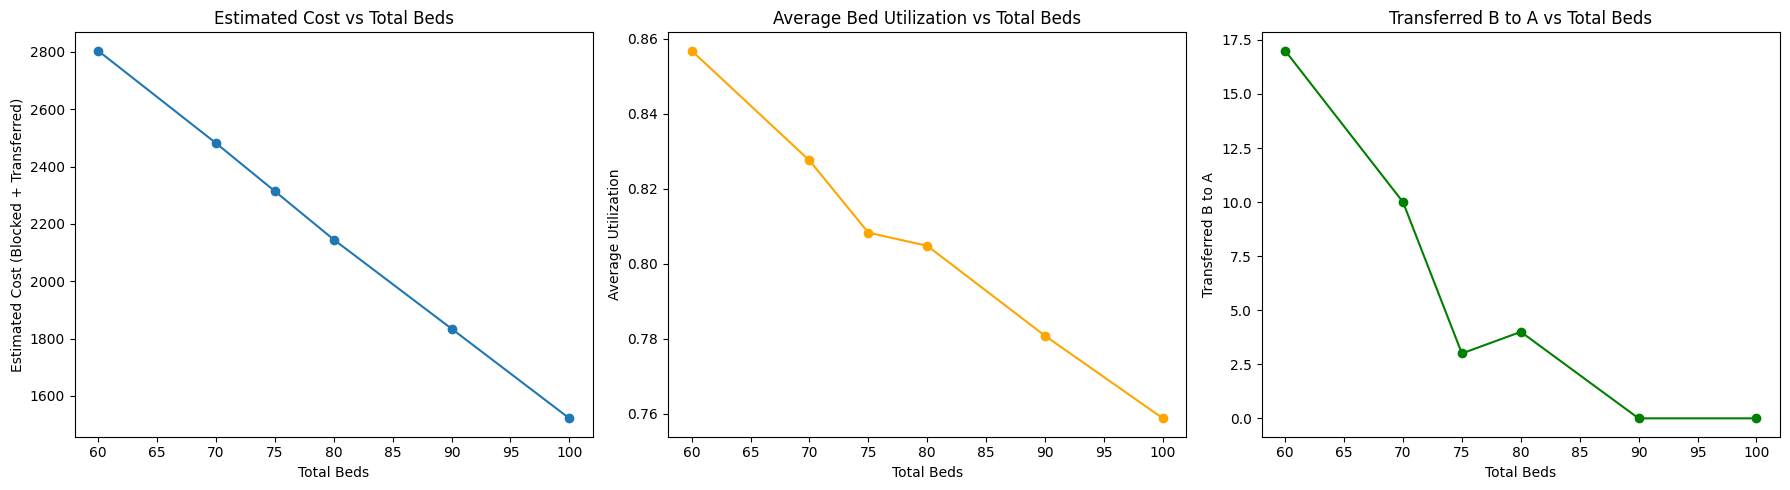

In [96]:
import matplotlib.pyplot as plt

total_beds_list = [r['total_beds'] for r in results_search]
cost_list = [r['best_cost'] for r in results_search]
avg_util_list = [(r['bed_utilization_A'] + r['bed_utilization_B'] + r['bed_utilization_C']) / 3 for r in results_search]
transferred_list = [r['transferred_B_to_A'] for r in results_search]

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(total_beds_list, cost_list, marker='o')
plt.title('Estimated Cost vs Total Beds')
plt.xlabel('Total Beds')
plt.ylabel('Estimated Cost (Blocked + Transferred)')

plt.subplot(1, 3, 2)
plt.plot(total_beds_list, avg_util_list, marker='o', color='orange')
plt.title('Average Bed Utilization vs Total Beds')
plt.xlabel('Total Beds')
plt.ylabel('Average Utilization')

plt.subplot(1, 3, 3)
plt.plot(total_beds_list, transferred_list, marker='o', color='green')
plt.title('Transferred B to A vs Total Beds')
plt.xlabel('Total Beds')
plt.ylabel('Transferred B to A')

plt.tight_layout()
plt.show()